<a href="https://colab.research.google.com/github/Fushionek/MLTraining/blob/main/Supervised/basics/california.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
from sklearn.datasets import fetch_california_housing


In [34]:
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [35]:
import seaborn as sns

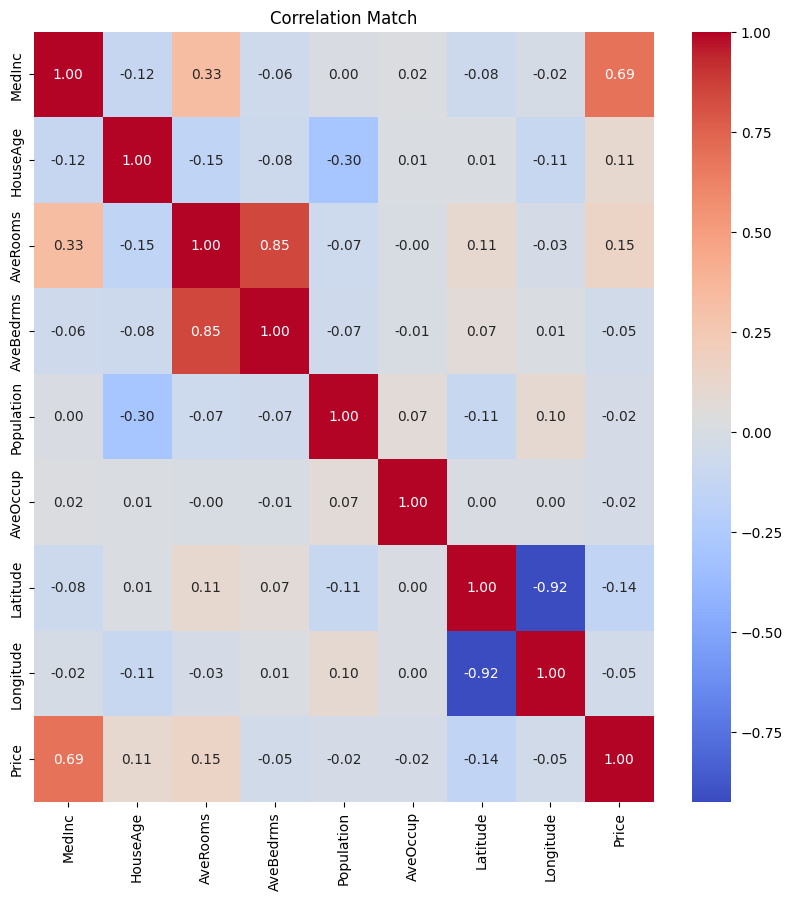

In [36]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Match')
plt.show()

In [37]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


In [38]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Price', axis=1)
y = df['Price']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

model_lr = LinearRegression().fit(X_train_scaled, y_train)
model_dt = DecisionTreeRegressor(max_depth=5).fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)
y_pred_dt = model_dt.predict(X_test_scaled)

In [41]:
print(f'Linear Regression MSE: {mean_squared_error(y_test, y_pred_lr)}')
print(f'Decision Tree MSE: {mean_squared_error(y_test, y_pred_dt)}')
print(f'Linear Regression R2: {r2_score(y_test, y_pred_lr)}')
print(f'Decision Tree R2: {r2_score(y_test, y_pred_dt)}')

Linear Regression MSE: 0.5558915986952442
Decision Tree MSE: 0.5245146178314735
Linear Regression R2: 0.575787706032451
Decision Tree R2: 0.5997321244428706


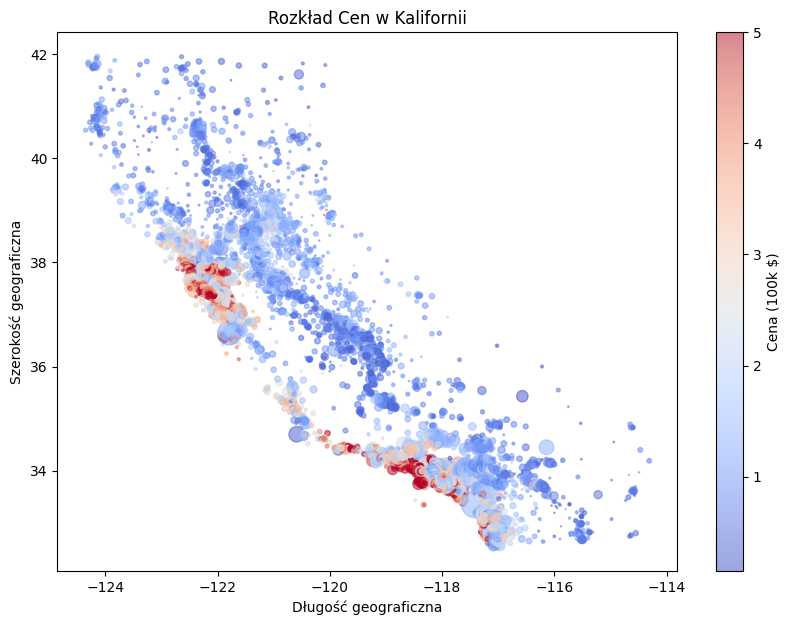

In [43]:
plt.figure(figsize=(10, 7))
plt.scatter(df['Longitude'], df['Latitude'], c=df['Price'], cmap='coolwarm', alpha=0.5, s=df['Population']/100)
plt.colorbar(label='Cena (100k $)')
plt.xlabel('Długość geograficzna')
plt.ylabel('Szerokość geograficzna')
plt.title('Rozkład Cen w Kalifornii')
plt.show()